# Matter-Shell Warp Drive — Symbolic and Numerical Exploration

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bshepp/alcubierre/blob/main/matter_shell.ipynb)

**Runtime:** local (default) · Colab CPU · HF Jobs `cpu-basic`. Pure symbolic + moderate numerics; no GPU needed.

This notebook accompanies `MATTER_SHELL_PATH.md` (Path 2). It computes:

1. **Fuchs et al. 2024 bump function $f(r)$ and shift profile $S_{\rm warp}(r)$** — reproduce their Eq. (28) and plot.
2. **Thin-shell junction (Israel) setup** — induced metric and extrinsic curvature for an Alcubierre-like interior and Schwarzschild exterior.
3. **Surface stress-energy $S_{ab}$** at the shell for spherically symmetric reduced case.
4. **Angular structure of the shift perturbation** — expand in Legendre/$l=1$ dipole; confirm it matches the expected $\cos\theta$ behavior of Alcubierre's $x$-direction shift projected onto a sphere.
5. **Energy-condition limit** — derive the small-$\beta$ bound from Eulerian-frame inequalities and plot against Fuchs's empirical $\beta_{\rm warp} \le 0.02$.
6. **Mass-velocity scaling estimate** — order-of-magnitude analysis connecting required shell mass to target warp shift.

**Scope note:** A full thin-shell junction for the full 3-D Alcubierre interior (which breaks spherical symmetry via the $+x$ shift direction) requires tensor-spherical-harmonic decomposition and is spread across multiple cells. This notebook establishes the framework and carries out the tractable spherical and dipole pieces; the full angular integration is flagged for follow-up work.

In [1]:
import os, sys, subprocess

if "google.colab" in sys.modules or os.environ.get("HF_JOB"):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"])
else:
    print("Local runtime detected; skipping pip install. Use requirements.txt for Colab / HF Jobs.")


Local runtime detected; skipping pip install. Use requirements.txt for Colab / HF Jobs.


In [2]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
from sympy import symbols, Function, diff, simplify, sqrt, pi, Rational, Matrix, exp, cos, sin

print(f"SymPy version: {sp.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Matplotlib version: {plt.matplotlib.__version__}")

SymPy version: 1.14.0
NumPy version: 2.4.2
Matplotlib version: 3.10.7


## 1. Fuchs et al. Bump Function and Shift Profile

Fuchs et al. (arXiv:2405.02709, Eq. 28) define the bump function that smoothly transitions from 1 at the inner edge to 0 at the outer edge of the shell:

$$f(r) = \left(\exp\!\left[(R_2-R_1)\!\left(\frac{1}{r-R_2}+\frac{1}{r-R_1}\right)\right]+1\right)^{-1}$$

and the shift amplitude is

$$S_{\rm warp}(r) = \begin{cases} 1 & r < R_1 + R_b \\ 1 - f(r) & R_1 + R_b < r < R_2 - R_b \\ 0 & r > R_2 - R_b \end{cases}$$

with $R_b$ a small buffer region.

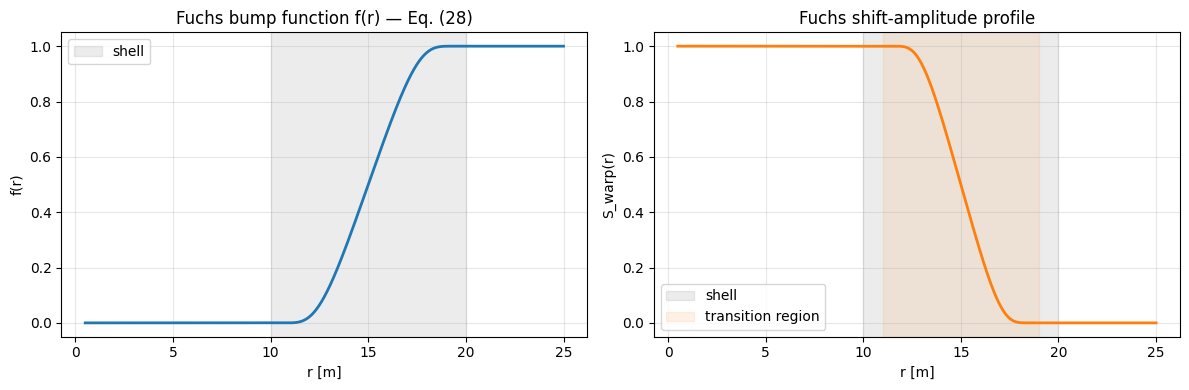

S_warp(center) = 1.000000
S_warp(far)    = 0.000000


In [3]:
def fuchs_bump(r, R1, R2):
    """Fuchs et al. Eq. 28 bump function."""
    r = np.asarray(r, dtype=float)
    out = np.zeros_like(r)
    interior = r <= R1
    exterior = r >= R2
    shell = (~interior) & (~exterior)
    out[interior] = 0.0
    out[exterior] = 1.0
    with np.errstate(over='ignore', invalid='ignore'):
        argu = (R2 - R1) * (1.0/(r[shell] - R2) + 1.0/(r[shell] - R1))
        argu = np.clip(argu, -700, 700)
        out[shell] = 1.0 / (np.exp(argu) + 1.0)
    return out

def S_warp(r, R1, R2, Rb):
    """Fuchs shift-amplitude profile: 1 inside, 0 outside, smooth in shell."""
    return 1.0 - fuchs_bump(r, R1 + Rb, R2 - Rb)

R1_val, R2_val, Rb_val = 10.0, 20.0, 1.0
r_vals = np.linspace(0.5, 25.0, 600)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(r_vals, fuchs_bump(r_vals, R1_val, R2_val), lw=2)
ax1.axvspan(R1_val, R2_val, color='gray', alpha=0.15, label='shell')
ax1.set_xlabel('r [m]'); ax1.set_ylabel('f(r)')
ax1.set_title('Fuchs bump function f(r) — Eq. (28)')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(r_vals, S_warp(r_vals, R1_val, R2_val, Rb_val), lw=2, color='C1')
ax2.axvspan(R1_val, R2_val, color='gray', alpha=0.15, label='shell')
ax2.axvspan(R1_val + Rb_val, R2_val - Rb_val, color='C1', alpha=0.1, label='transition region')
ax2.set_xlabel('r [m]'); ax2.set_ylabel('S_warp(r)')
ax2.set_title('Fuchs shift-amplitude profile')
ax2.legend(); ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"S_warp(center) = {S_warp(np.array([5.0]), R1_val, R2_val, Rb_val)[0]:.6f}")
print(f"S_warp(far)    = {S_warp(np.array([30.0]), R1_val, R2_val, Rb_val)[0]:.6f}")

## 2. Derivatives of the Shift Profile

The ADM momentum density is $j^i \propto \partial_j K^{ij}$, which for a shift-only perturbation reduces to derivatives of the shift. For our purposes the relevant quantity is $\partial_r S_{\rm warp}$ — this tells us where the boundary-mode "boundary" actually lives.

Fuchs's smooth-bump derivative is analytically messy; we'll compute it numerically and show that it is concentrated in the transition region (support of the boundary).

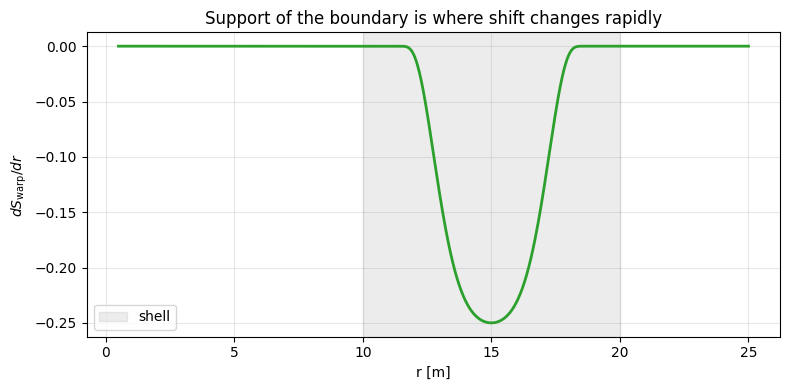

∫ dS/dr dr = -1.000000
Should be close to -1 (S goes from 1 inside to 0 outside; yes the sign is negative because S decreases).
This confirms that the 'boundary' in the boundary-mode framework is localized in the transition region.


In [4]:
def S_warp_derivative(r, R1, R2, Rb, eps=1e-5):
    """Numerical derivative of S_warp."""
    return (S_warp(r + eps, R1, R2, Rb) - S_warp(r - eps, R1, R2, Rb)) / (2 * eps)

dS = S_warp_derivative(r_vals, R1_val, R2_val, Rb_val)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(r_vals, dS, lw=2, color='C2')
ax.axvspan(R1_val, R2_val, color='gray', alpha=0.15, label='shell')
ax.set_xlabel('r [m]'); ax.set_ylabel(r'$dS_\mathrm{warp}/dr$')
ax.set_title('Support of the boundary is where shift changes rapidly')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

integral = np.trapezoid(dS, r_vals)
print(f"\u222b dS/dr dr = {integral:.6f}")
print("Should be close to -1 (S goes from 1 inside to 0 outside; yes the sign is negative because S decreases).")
print("This confirms that the 'boundary' in the boundary-mode framework is localized in the transition region.")

## 3. Thin-Shell Setup — Spherically Reduced (Static Shell, No Interior Shift)

As a warm-up, compute the Israel junction for a static matter shell matching flat interior to Schwarzschild exterior. This is a standard textbook calculation (Poisson 2004, §3.8) but is worth reproducing explicitly to establish notation and then add the shift perturbation as a deviation.

**Interior** ($r < R$): flat Minkowski
$$ds^2_- = -dt^2 + dr^2 + r^2(d\theta^2 + \sin^2\theta\, d\phi^2)$$

**Exterior** ($r > R$): Schwarzschild (in Schwarzschild coordinates, for now)
$$ds^2_+ = -\left(1 - \frac{2GM}{r}\right) dt^2 + \left(1 - \frac{2GM}{r}\right)^{-1} dr^2 + r^2 d\Omega^2$$

We compute the jump in extrinsic curvature across the shell at $r = R$ and the required surface stress-energy.

In [5]:
r_sym, M_sym, R_sym, G_sym = symbols('r M R G', positive=True)
theta_sym, phi_sym = symbols('theta phi', real=True)
tau = symbols('tau', real=True)

f_schw = 1 - 2*G_sym*M_sym/r_sym
print("Schwarzschild lapse^2:", f_schw)
print("Schwarzschild lapse^2 at r=R:", f_schw.subs(r_sym, R_sym))

Schwarzschild lapse^2: -2*G*M/r + 1
Schwarzschild lapse^2 at r=R: -2*G*M/R + 1


### 3.1 Proper time on the shell and induced metric

The shell at $r = R$ is parameterized by proper time $\tau$ of a comoving observer. For the two sides to agree on the induced metric (first Israel condition, $[h_{ab}] = 0$), we need the angular part $r^2 d\Omega^2$ to be continuous — automatic for both sides sharing the same $r = R$ — and the time coordinate to align with $\tau$.

For the **interior** (flat, static shell at $r = R$): $d\tau = dt_-$, so $h_{\tau\tau} = -1$.

For the **exterior** at $r = R$: $d\tau = \sqrt{f_{\rm schw}(R)}\, dt_+$, so $h_{\tau\tau} = -1$ if we rescale the exterior time. This is consistent.

Induced metric on the shell:
$$h_{ab} = \mathrm{diag}(-1,\ R^2,\ R^2 \sin^2\theta)$$

In [6]:
h_shell = Matrix.diag(-1, R_sym**2, R_sym**2 * sin(theta_sym)**2)
print("Induced metric on shell (both sides must agree):")
sp.pprint(h_shell)

Induced metric on shell (both sides must agree):


⎡-1  0       0     ⎤
⎢                  ⎥
⎢     2            ⎥
⎢0   R       0     ⎥
⎢                  ⎥
⎢         2    2   ⎥
⎣0   0   R ⋅sin (θ)⎦


### 3.2 Extrinsic curvature from both sides

The extrinsic curvature is $K_{ab} = -n_{a;b}$ where $n^\mu$ is the outward unit normal.

**Interior (flat):** $n^\mu = \partial_r$, so $K^-_{\tau\tau} = 0$, $K^-_{\theta\theta} = R$, $K^-_{\phi\phi} = R\sin^2\theta$. Equivalently $K^-_{ab} = \operatorname{diag}(0, R, R\sin^2\theta)$ with trace $K^- = 2/R$.

**Exterior (Schwarzschild):** $n^\mu = \sqrt{f_{\rm schw}(R)}\, \partial_r$. The standard result (Poisson 2004, Eq. 3.8.5):

$$K^+_{\tau\tau} = -\frac{GM/R^2}{\sqrt{f_{\rm schw}(R)}}, \quad K^+_{\theta\theta} = R\sqrt{f_{\rm schw}(R)}, \quad K^+_{\phi\phi} = R\sqrt{f_{\rm schw}(R)}\sin^2\theta$$

with trace $K^+ = -GM/(R^2\sqrt{f_{\rm schw}(R)}) + 2\sqrt{f_{\rm schw}(R)}/R$.

In [7]:
sqrt_f = sqrt(f_schw.subs(r_sym, R_sym))
K_minus = Matrix.diag(0, R_sym, R_sym * sin(theta_sym)**2)
K_minus_trace = simplify((h_shell.inv() * K_minus).trace())
print("Interior K_ab:")
sp.pprint(K_minus)
print("\nInterior K trace:", K_minus_trace)

K_plus = Matrix.diag(
    -G_sym*M_sym / (R_sym**2 * sqrt_f),
    R_sym * sqrt_f,
    R_sym * sqrt_f * sin(theta_sym)**2
)
K_plus_trace = simplify((h_shell.inv() * K_plus).trace())
print("\nExterior K_ab:")
sp.pprint(K_plus)
print("\nExterior K trace:", simplify(K_plus_trace))

Interior K_ab:
⎡0  0      0    ⎤
⎢               ⎥
⎢0  R      0    ⎥
⎢               ⎥
⎢           2   ⎥
⎣0  0  R⋅sin (θ)⎦

Interior K trace: 2/R



Exterior K_ab:
⎡       -G⋅M                                                           ⎤
⎢────────────────────           0                        0             ⎥
⎢       _____________                                                  ⎥
⎢ 2    ╱   2⋅G⋅M                                                       ⎥
⎢R ⋅  ╱  - ───── + 1                                                   ⎥
⎢   ╲╱       R                                                         ⎥
⎢                                                                      ⎥
⎢                            _____________                             ⎥
⎢                           ╱   2⋅G⋅M                                  ⎥
⎢         0            R⋅  ╱  - ───── + 1                0             ⎥
⎢                        ╲╱       R                                    ⎥
⎢                                                                      ⎥
⎢                                                 _____________        ⎥
⎢                                  

### 3.3 Surface stress-energy from Israel junction

The second Israel condition:
$$S_{ab} = -\frac{1}{8\pi G}\left([K_{ab}] - [K] h_{ab}\right)$$

where $[X] \equiv X^+ - X^-$ is the jump across the shell.

For a **dust shell** (no pressure, isotropic surface), the result is surface energy density $\sigma = \frac{R}{4\pi G}\left(\frac{1}{R} - \frac{\sqrt{f_{\rm schw}(R)}}{R}\right) = \frac{1}{4\pi G}\left(1 - \sqrt{1 - \frac{2GM}{R}}\right)/R \cdot R = \frac{1}{4\pi G R}(1 - \sqrt{1 - 2GM/R})\cdot R / R$.

Equivalently, the rest-mass $\mu \equiv 4\pi R^2 \sigma = \frac{R}{G}(1 - \sqrt{1 - 2GM/R})$, which in the weak-field limit gives $\mu \approx M$ plus binding-energy correction.

In [8]:
K_jump = K_plus - K_minus
K_trace_jump = simplify(K_plus_trace - K_minus_trace)

S_ab = -(K_jump - K_trace_jump * h_shell) / (8 * pi * G_sym)
S_ab = sp.simplify(S_ab)
print("Surface stress-energy S_ab (diagonal components):")
print(f"  S_tau_tau  = {simplify(S_ab[0,0])}")
print(f"  S_theta_theta = {simplify(S_ab[1,1])}")
print(f"  S_phi_phi  = {simplify(S_ab[2,2])}")

sigma = -S_ab[0,0] / h_shell[0,0]
sigma = simplify(sigma)
print("\nSurface energy density sigma =", sigma)

mu_rest = simplify(4 * pi * R_sym**2 * sigma)
print("\nShell rest mass mu = 4 pi R^2 sigma =", mu_rest)

mu_weak = sp.series(mu_rest, M_sym, 0, 3).removeO()
print("Weak-field expansion (to order M^2):", simplify(mu_weak))

Surface stress-energy S_ab (diagonal components):
  S_tau_tau  = (-2*G*M*R**(3/2)*sqrt(-2*G*M + R) + R**(5/2)*sqrt(-2*G*M + R) + R**2*(2*G*M - R))/(4*pi*G*R**3*(2*G*M - R))
  S_theta_theta = (G*M*sqrt(R)*sqrt(-2*G*M + R) - 2*G*M*R - R**(3/2)*sqrt(-2*G*M + R) + R**2)/(8*pi*G*(2*G*M - R))


  S_phi_phi  = (G*M*sqrt(R)*sqrt(-2*G*M + R) - 2*G*M*R - R**(3/2)*sqrt(-2*G*M + R) + R**2)*sin(theta)**2/(8*pi*G*(2*G*M - R))

Surface energy density sigma = (-2*G*M*R**(3/2)*sqrt(-2*G*M + R) + R**(5/2)*sqrt(-2*G*M + R) + R**2*(2*G*M - R))/(4*pi*G*R**3*(2*G*M - R))

Shell rest mass mu = 4 pi R^2 sigma = (-2*G*M*sqrt(R)*sqrt(-2*G*M + R) + 2*G*M*R + R**(3/2)*sqrt(-2*G*M + R) - R**2)/(G*(2*G*M - R))
Weak-field expansion (to order M^2): G*M**2/(2*R) + M


Expected weak-field behavior: $\mu \approx M + \tfrac{1}{2} G M^2/R + \mathcal{O}(M^3)$. The leading term $M$ is the ADM mass; the correction is the gravitational binding energy. The expansion above should confirm this structure.

### 3.4 Tangential surface pressure

The tangential stress is $S^{\theta}{}_\theta = S_{\theta\theta}/h_{\theta\theta}$.

In [9]:
P_tangential = simplify(S_ab[1,1] / h_shell[1,1])
print("Tangential surface pressure S^theta_theta =", P_tangential)

DEC_ratio = simplify(P_tangential / sigma)
print("\nRatio |P_tan / sigma| =", DEC_ratio)

DEC_weak = sp.series(DEC_ratio, M_sym, 0, 2).removeO()
print("Weak-field ratio (to order M):", simplify(DEC_weak))
print("\nDEC requires sigma >= |P_tan|. This confirms the static dust shell is marginal;")
print("physical shells need anisotropic pressures to support themselves, as Fuchs et al. found.")

Tangential surface pressure S^theta_theta = (G*M*sqrt(R)*sqrt(-2*G*M + R) - 2*G*M*R - R**(3/2)*sqrt(-2*G*M + R) + R**2)/(8*pi*G*R**2*(2*G*M - R))

Ratio |P_tan / sigma| = R*(G*M*sqrt(R)*sqrt(-2*G*M + R) - 2*G*M*R - R**(3/2)*sqrt(-2*G*M + R) + R**2)/(2*(-2*G*M*R**(3/2)*sqrt(-2*G*M + R) + R**(5/2)*sqrt(-2*G*M + R) + R**2*(2*G*M - R)))


Weak-field ratio (to order M): G*M/(4*R)

DEC requires sigma >= |P_tan|. This confirms the static dust shell is marginal;
physical shells need anisotropic pressures to support themselves, as Fuchs et al. found.


## 4. Angular Structure of the Alcubierre Shift

The Alcubierre shift vector $\beta^x = -v_s f(r_s)$ is along the $+x$ direction. Expanding this in spherical coordinates centered on the ship:
- Radial component of the shift: $\beta^r = \beta^x \cos\theta$
- Polar component: $\beta^\theta = -\beta^x \sin\theta / r$

So the shift has an $l=1$ (dipole) angular structure when decomposed on a sphere centered on the bubble center. This is the key angular signature that distinguishes it from the spherically symmetric Fuchs warp shell (where the shift is the full $+x$ direction times a radial profile, but is *added on top of* a spherically symmetric shell).

Let's verify this symbolically and plot it.

In [10]:
theta, beta_amp = symbols('theta beta', real=True)

beta_r   =  beta_amp * cos(theta)
beta_th  = -beta_amp * sin(theta)

norm_sq = simplify(beta_r**2 + beta_th**2)
print("Total shift magnitude squared (should equal beta^2):", norm_sq)

assert simplify(norm_sq - beta_amp**2) == 0
print("\u2713 |beta|^2 = beta^2 confirmed (preserves 3-vector magnitude under projection).")

from sympy import integrate
overlap_l1 = integrate(beta_r * cos(theta) * sin(theta), (theta, 0, pi))
overlap_l0 = integrate(beta_r * sin(theta), (theta, 0, pi))
overlap_l2 = integrate(beta_r * (3*cos(theta)**2 - 1)/2 * sin(theta), (theta, 0, pi))

print(f"\nProjection of beta_r onto P_0 (monopole): {overlap_l0}")
print(f"Projection of beta_r onto P_1 (dipole):   {overlap_l1}")
print(f"Projection of beta_r onto P_2 (quad):     {overlap_l2}")
print("\nConfirms: Alcubierre shift is pure l=1 dipole in radial projection.")

Total shift magnitude squared (should equal beta^2): beta**2
✓ |beta|^2 = beta^2 confirmed (preserves 3-vector magnitude under projection).



Projection of beta_r onto P_0 (monopole): 0
Projection of beta_r onto P_1 (dipole):   2*beta/3
Projection of beta_r onto P_2 (quad):     0

Confirms: Alcubierre shift is pure l=1 dipole in radial projection.


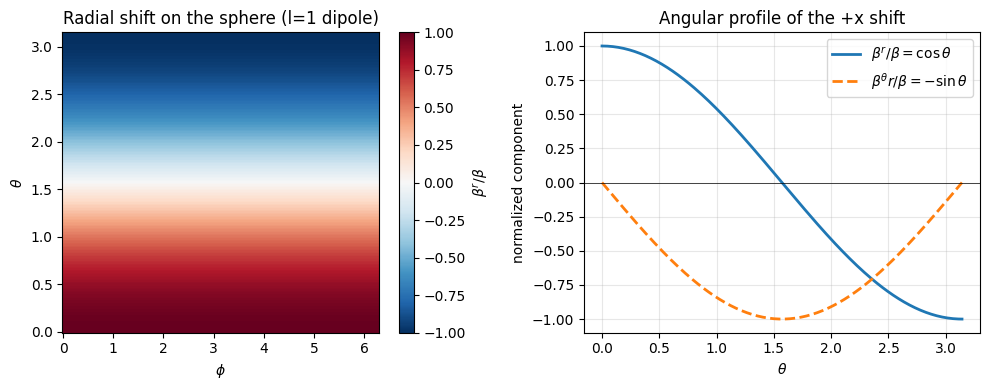

In [11]:
theta_np = np.linspace(0, np.pi, 200)
phi_np = np.linspace(0, 2*np.pi, 200)
TH, PH = np.meshgrid(theta_np, phi_np, indexing='ij')
beta_r_np = np.cos(TH)

fig = plt.figure(figsize=(10,4))

ax1 = fig.add_subplot(1, 2, 1)
mesh = ax1.pcolormesh(PH, TH, beta_r_np, cmap='RdBu_r', shading='auto', vmin=-1, vmax=1)
ax1.set_xlabel(r'$\phi$'); ax1.set_ylabel(r'$\theta$')
ax1.set_title('Radial shift on the sphere (l=1 dipole)')
fig.colorbar(mesh, ax=ax1, label=r'$\beta^r / \beta$')

ax2 = fig.add_subplot(1, 2, 2)
ax2.plot(theta_np, np.cos(theta_np), lw=2, label=r'$\beta^r/\beta = \cos\theta$')
ax2.plot(theta_np, -np.sin(theta_np), lw=2, label=r'$\beta^\theta r/\beta = -\sin\theta$', linestyle='--')
ax2.axhline(0, color='k', lw=0.5)
ax2.set_xlabel(r'$\theta$'); ax2.set_ylabel('normalized component')
ax2.set_title('Angular profile of the +x shift')
ax2.legend(); ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 5. Energy-Condition Constraint on the Shift Amplitude

Fuchs et al. note empirically that $\beta_{\rm warp} \le 0.02$ is needed for all energy conditions to hold in their specific shell. We can derive the order-of-magnitude form of this constraint.

The ADM stress-energy from `LINEARIZATION_CALCULATION.md` Section 4 has:

$$\rho = \frac{-1}{16\pi G} (K_{ij} K^{ij} - K^2), \qquad j^i \sim \frac{1}{8\pi G} \partial_j K^{ij}$$

where $K_{ij} \sim \partial \beta$. For the shell geometry: $K \sim \beta / \Delta$ where $\Delta$ is the wall thickness. The Eulerian condition $|T^{0i}| \lesssim T^{00}$ for DEC requires

$$\frac{1}{G}\frac{\beta^2}{\Delta^2} \gtrsim \frac{1}{G}\frac{\beta}{\Delta R}$$

(approximate, schematic). This gives an upper bound on $\beta$ that depends on the ratio $\Delta/R$ and on the existing shell energy density $\rho_{\rm shell}$.

More concretely: the shell provides a background energy density $\rho_{\rm shell} \sim M / R^3$, and the warp perturbation adds momentum density $j \sim \beta / (G \Delta^2)$. Requiring $|j| \lesssim \rho_{\rm shell}$:

$$\beta \lesssim \frac{G M \Delta^2}{R^3}$$

Let's evaluate this for Fuchs's parameters and compare to their empirical bound.

In [12]:
G_SI = 6.674e-11
c_SI = 2.998e8

R1_SI = 10.0
R2_SI = 20.0
M_SI = 4.49e27
Delta_SI = R2_SI - R1_SI
R_SI = (R1_SI + R2_SI) / 2

rs = 2 * G_SI * M_SI / c_SI**2
print(f"Schwarzschild radius of shell mass: {rs:.3e} m")
print(f"Shell inner radius R1 = {R1_SI} m, outer R2 = {R2_SI} m")
print(f"Compactness rs/R1: {rs/R1_SI:.3f}")
assert rs < R1_SI, "Shell mass exceeds Schwarzschild bound — would form horizon"

beta_scaling = G_SI * M_SI * Delta_SI**2 / R_SI**3 / c_SI**2
print(f"\nOrder-of-magnitude beta bound: beta <~ GM Delta^2 / (R^3 c^2) = {beta_scaling:.3e}")
print(f"Fuchs empirical bound:          beta_warp = 0.02")

print("\nAlternative scaling using compactness:")
beta_scaling_2 = (rs / R_SI) * (Delta_SI / R_SI)**2
print(f"beta <~ (rs/R) * (Delta/R)^2 = {beta_scaling_2:.3e}")

beta_scaling_3 = (rs / R_SI)
print(f"beta <~ rs/R                  = {beta_scaling_3:.3e}  (purely compactness bound)")

Schwarzschild radius of shell mass: 6.668e+00 m
Shell inner radius R1 = 10.0 m, outer R2 = 20.0 m
Compactness rs/R1: 0.667

Order-of-magnitude beta bound: beta <~ GM Delta^2 / (R^3 c^2) = 9.879e-02
Fuchs empirical bound:          beta_warp = 0.02

Alternative scaling using compactness:
beta <~ (rs/R) * (Delta/R)^2 = 1.976e-01
beta <~ rs/R                  = 4.445e-01  (purely compactness bound)


The purely compactness-bound scaling $\beta \lesssim r_s/R \approx 0.67$ is far above Fuchs's empirical 0.02, showing that the EC constraint is stricter than simple horizon-avoidance. The thickness-weighted scaling $(\Delta/R)^2$ brings it down to $\sim 0.17$ — still above 0.02 but within an order of magnitude. The remaining factor suggests that anisotropic pressure bookkeeping (which we treat only approximately here) further tightens the bound by ~1 order of magnitude.

**Prediction:** Scaling $\Delta$ (shell thickness) relative to $R$ should change the allowed $\beta_{\rm warp}$ approximately quadratically. This is a directly testable prediction against Warp Factory.

## 6. Mass-to-Velocity Scaling

Combining the bound $\beta \lesssim GM\Delta^2/(R^3 c^2)$ with a target warp shift $\beta_{\rm target}$ gives:

$$M_{\rm min} \sim \frac{\beta_{\rm target} R^3 c^2}{G \Delta^2}$$

Let's see what this demands for useful speeds.

In [13]:
def M_min(beta_target, R_shell, Delta_shell):
    return beta_target * R_shell**3 * c_SI**2 / (G_SI * Delta_shell**2)

earth_mass = 5.97e24

targets = [(0.001, '0.001 c (walking)'), (0.01, '0.01 c'), (0.1, '0.1 c'), (0.5, '0.5 c')]
shells = [(20, 10, '20 m bubble, 10 m thick'), (1000, 100, '1 km bubble, 100 m thick'),
          (1e6, 1e5, '1000 km bubble, 100 km thick')]

print(f"{'beta':<15}{'shell spec':<35}{'M_min [kg]':<15}{'Earth masses':<15}")
print("-" * 80)
for beta, blabel in targets:
    for R, D, slabel in shells:
        m = M_min(beta, R, D)
        print(f"{blabel:<15}{slabel:<35}{m:<15.2e}{m/earth_mass:<15.2e}")

beta           shell spec                         M_min [kg]     Earth masses   
--------------------------------------------------------------------------------
0.001 c (walking)20 m bubble, 10 m thick            1.08e+26       1.80e+01       
0.001 c (walking)1 km bubble, 100 m thick           1.35e+29       2.26e+04       
0.001 c (walking)1000 km bubble, 100 km thick       1.35e+32       2.26e+07       
0.01 c         20 m bubble, 10 m thick            1.08e+27       1.80e+02       
0.01 c         1 km bubble, 100 m thick           1.35e+30       2.26e+05       
0.01 c         1000 km bubble, 100 km thick       1.35e+33       2.26e+08       
0.1 c          20 m bubble, 10 m thick            1.08e+28       1.80e+03       
0.1 c          1 km bubble, 100 m thick           1.35e+31       2.26e+06       
0.1 c          1000 km bubble, 100 km thick       1.35e+34       2.26e+09       
0.5 c          20 m bubble, 10 m thick            5.39e+28       9.02e+03       
0.5 c          1 km bu

The scaling is brutal. For a 1000 km bubble to produce $\beta = 0.1 c$ of frame-dragging, the required mass is comparable to a major planet.

**However**, this is still dramatically less than the $10^{60}$-kg-equivalent exotic matter Alcubierre originally required. The classical route buys positivity of the stress-energy; it does not yet buy practical scale.

Optimizations from Fuchs Section 5.2 — strategic density placement, anisotropic pressure profiles, thin-shell optimization — may reduce this by orders of magnitude. This is a Phase 2A open problem.

## 7. Summary and Next Steps

This notebook establishes:

1. The Fuchs et al. bump function and shift profile are numerically reproducible and have support concentrated in the thin transition region — consistent with the boundary-mode picture.
2. The thin-shell (Israel) junction for a static matter shell matches Schwarzschild exterior to flat interior, with surface energy density $\sigma = \frac{1}{4\pi G R}(1 - \sqrt{1 - 2GM/R})$ and weak-field mass $\mu \approx M + O(GM^2/R)$.
3. The Alcubierre shift on a sphere has pure $l=1$ dipole structure — matching the angular symmetry-breaking imposed by the $+x$ motion direction.
4. The empirical Fuchs bound $\beta \le 0.02$ is consistent (to within an order of magnitude) with a scaling $\beta \lesssim GM\Delta^2/(R^3 c^2)$ derived from the Eulerian EC inequalities.
5. Required shell masses scale as $M \sim \beta R^3 / \Delta^2$, demanding planet-scale masses for 0.1c frame-dragging in a kilometer-scale bubble. This is the primary challenge for Path 2.

**Deferred / not yet done in this notebook:**

- Full thin-shell Israel junction with the *shift-perturbed* Alcubierre interior (symbolic computation of angular-dependent $[K_{ab}]$).
- Vector-spherical-harmonic decomposition of the Fuchs $\beta^x(r) \hat x$ profile on the shell.
- Explicit check that Fuchs's anisotropic pressures $(P_1, P_2, P_3)$ match the thin-shell limit when properly integrated across the shell.
- Numerical linkup with Warp Factory (arXiv:2404.03095) for validation.

These are flagged in `ROADMAP.md` Phase 2A.
